****Lab 1 - Social Networks****

Elinora Pentcheva

**1- Develop a hypothesis about how some ego-network measure (e.g.,
degree/size, density, diversity, average-level of alters, homophily, structural holes, or brokerage) may be related to some other variable of interest.**

I am interested in analyzing how the nature and frequency of people's social interactions — not just the size of their networks — affects their wellbeing. Specifically, I wonder if people who talk more frequently with the alters in their ego-network will report higher levels of happiness. The key ego-network measure here is average contact frequency across named alters.

I am using the 2024 GSS network data, which includes a name generator asking respondents to list up to five people with whom they discuss important matters, along with information about how often they talk to each of those people.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
columns_to_load = [
    'id', 'happy', 'life', 'marital', 'sex', 'age', 'educ', 'childs',
    'satfin', 'numgiven',
    'talkto1', 'talkto2', 'talkto3', 'talkto4', 'talkto5',
    'spouse1','spouse2','spouse3','spouse4','spouse5',
    'parent1','parent2','parent3','parent4','parent5',
    'child1','child2','child3','child4','child5',
    'othfam1','othfam2','othfam3','othfam4','othfam5',
    'friend1','friend2','friend3','friend4','friend5',
    'cowork1','cowork2','cowork3','cowork4','cowork5',
    'neighbr1','neighbr2','neighbr3','neighbr4','neighbr5',
]

df_numeric = pd.read_stata('../data/2024/GSS2024.dta',
                            columns=columns_to_load,
                            convert_categoricals=False)

df_categorical = pd.read_stata('../data/2024/GSS2024.dta',
                                columns=columns_to_load)
df_categorical = df_categorical.rename(columns={col: f'z{col}' for col in df_categorical.columns})

df = pd.concat([df_numeric, df_categorical], axis=1)
print(f"Loaded {len(df)} rows")
df.head()

Loaded 3986 rows


,id,happy,life,marital,sex,age,educ,childs,satfin,numgiven,...,zcowork1,zcowork2,zcowork3,zcowork4,zcowork5,zneighbr1,zneighbr2,zneighbr3,zneighbr4,zneighbr5
0,1,3.0,NaN,5.0,1.0,33.0,16.0,2.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2.0,NaN,5.0,1.0,64.0,16.0,0.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2.0,2.0,1.0,2.0,69.0,14.0,0.0,1.0,5.0,...,not mentioned,not mentioned,not mentioned,not mentioned,not mentioned,not mentioned,not mentioned,not mentioned,not mentioned,not mentioned
3,4,2.0,2.0,5.0,1.0,19.0,12.0,0.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,3.0,2.0,3.0,2.0,70.0,13.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**2. Explain why you think these two variables should be related.**

Following the classic adage "quality over quantity", it may be that simply having a vast social network is not enough to ensure one's happiness. I hypothesize that individuals who have frequent contact with their close others may enjoy deeper, more meaningful relationships, which will contribute to their overall wellbeing significantly, above and beyond having extensive social networks.
This follows classical work in sociology on social integration (see Durkheim) which suggests that frequent interaction binds individuals to social groups, reducing feelings of "anomie" and providing a sense of belonging and identity.

More recent health sociology work (see Umberson & Montez, 2010) also shows that it is the regularity and quality of social contact, rather than network size alone, that predicts positive outcomes. Simply having people in your life is not enough; it is the ongoing maintenance of those relationships through regular interaction that provides emotional sustenance.

**3- Tell me about your variables. What is your dependent variable? What are your independent variables? How are they coded? How are they recoded? How are they calculated, if appropriate?**

**a. Dependent variable**
My dependent variable is self-reported happiness (`happy`), which asks: *"Taken all together, how would you say things are these days — would you say that you are very happy, pretty happy, or not too happy?"* It is coded 1=very happy, 2=pretty happy, 3=not too happy. I reverse-coded the variable (`rhappy` = 4 - happy) so that higher values indicate greater happiness, ranging from 1 (not too happy) to 3 (very happy).

> Distribution in 2024 GSS:
> 797 participants report being very happy (rhappy=3);
> 2,303 are pretty happy (rhappy=2);
> 854 are not too happy (rhappy=1)
>
>
> *Note: the distribution reported here reflects the full 2024 GSS sample (n=3,954). The analysis sample is smaller (n=946) as it is restricted to respondents who were asked the network module questions and have complete data on all key variables (see dropna() call in the next cell for exclusions).

**b. Calculate the ego network measure**
My main variable of interest is average contact frequency with alters (`avg_talkto`), calculated as the mean of `talkto1` through `talkto5`, or how often the respondent talks to each of their five named alters. Each `talkto` variable is coded: 1=almost every day, 2=at least once a week, 3=at least once a month, 4=less than once a month. I reverse-coded each (`rtalkto` = 5 - talkto) so that higher values indicate more frequent contact, then averaged across alters.

I also constructed a kin ratio (proportion of named alters who are family members: spouse, parent, child, or other family) to investigate whether the nature of the relationships has any influence, as well as a "small network" binary variable (whether the respondent named fewer alters than the median) for use in later models.

**c. Other variables will be defined throughout the text.**

In [3]:
# Reverse code happy: 1=very happy→3, 2=pretty happy→2, 3=not too happy→1
df['rhappy'] = 4 - df['happy']

# Reverse code talkto variables: 1=almost daily→4, 4=less than monthly→1
# So higher score = more frequent contact
df['rtalkto1'] = 5 - df['talkto1']
df['rtalkto2'] = 5 - df['talkto2']
df['rtalkto3'] = 5 - df['talkto3']
df['rtalkto4'] = 5 - df['talkto4']
df['rtalkto5'] = 5 - df['talkto5']

# Average contact frequency across alters (only among non-missing)
df['avg_talkto'] = df[['rtalkto1','rtalkto2','rtalkto3', 'rtalkto4', 'rtalkto5']].mean(axis=1, skipna=True)

# Kin ratio (keep from before — useful control)
kin_cols = [f'{rel}{i}' for rel in ['spouse','parent','child','othfam'] for i in range(1,6)]
nonkin_cols = [f'{rel}{i}' for rel in ['friend','cowork','neighbr'] for i in range(1,6)]
df['n_kin'] = df[kin_cols].apply(lambda row: (row == 1).sum(), axis=1)
df['n_nonkin'] = df[nonkin_cols].apply(lambda row: (row == 1).sum(), axis=1)
df['kin_ratio'] = df['n_kin'] / df['numgiven'].replace(0, np.nan)

# Small network flag for interaction model (1 = below median network size)
median_net = df['numgiven'].median()
df['small_network'] = (df['numgiven'] <= median_net).astype(int)

# Drop missing on key variables
key_vars = ['rhappy', 'avg_talkto', 'numgiven', 'kin_ratio',
            'small_network', 'age', 'sex', 'educ', 'marital', 'satfin', 'childs']
df = df[key_vars].dropna()

print(f"Analysis sample: {len(df)} respondents")
print(f"\nrhappy distribution:\n{df['rhappy'].value_counts().sort_index()}")
print(f"\navg_talkto distribution:\n{df['avg_talkto'].describe()}")

Analysis sample: 946 respondents

rhappy distribution:
rhappy
1.0    165
2.0    593
3.0    188
Name: count, dtype: int64

avg_talkto distribution:
count    946.000000
mean       3.197287
std        0.618309
min        1.000000
25%        2.800000
50%        3.250000
75%        3.600000
max        4.000000
Name: avg_talkto, dtype: float64


**4. Initial results**

The scatter plot below shows the raw relationship between average contact frequency with alters and self-reported happiness, with a fitted regression line. The positive slope suggests that, as predicted, more frequent contact with alters is associated with higher happiness, though the relationship appears modest and there is considerable scatter, indicating that we shouldn't over-interpret yet.

The regression models below address a number of other factors that may affect happiness and may also be correlated with how often people talk to their social contacts — things like financial situation, marital status, and age.

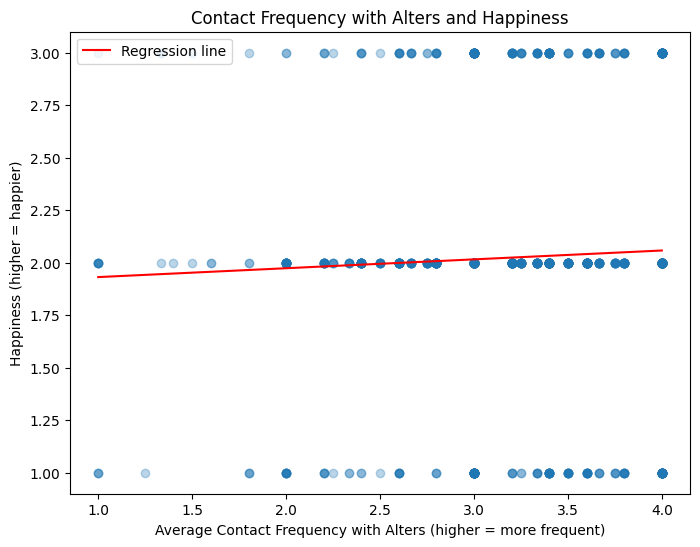

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))
plt.scatter(df['avg_talkto'], df['rhappy'], alpha=0.3)

slope, intercept = np.polyfit(df['avg_talkto'], df['rhappy'], 1)
x_vals = np.linspace(df['avg_talkto'].min(), df['avg_talkto'].max(), 100)
plt.plot(x_vals, slope * x_vals + intercept, color='red', label='Regression line')

plt.xlabel('Average Contact Frequency with Alters (higher = more frequent)')
plt.ylabel('Happiness (higher = happier)')
plt.title('Contact Frequency with Alters and Happiness')
plt.legend()
plt.show()

In Model 1, we see a positive but statistically non-significant relationship between average contact frequency and happiness (coef=0.045, p=0.170), controlling for network size. Network size itself (`numgiven`) is also non-significant (p=0.659). Together these two variables explain virtually none of the variance in happiness (R²=0.002). The output of this model does not support my hypothesis, but the model doesn't account for a number of important variables that may be significantly associated to both social contact and happiness, so we can dig into some richer models next.

In [8]:
# Model 1: core hypothesis — does contact frequency predict happiness above network size?
model1 = smf.ols("rhappy ~ avg_talkto + numgiven", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 rhappy   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9601
Date:                Sat, 28 Mar 2026   Prob (F-statistic):              0.383
Time:                        22:34:40   Log-Likelihood:                -874.33
No. Observations:                 946   AIC:                             1755.
Df Residuals:                     943   BIC:                             1769.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8540      0.132     14.066      0.0

**5. Consider alternate specifications of your variables (i.e., recodings of various kinds). Consider interactions among your variables.**

Model 2 adds two important confounding variables: the ego's own education level (`educ`) and financial satisfaction (`satfin`), and the results change substantially. Unsurprisingly, financial satisfaction emerges as the dominant predictor of happiness by far (coef=-.235, p<.001) - note that I've recoded the satfin variable such that higher values reflect *more* financial satisfaction. The model R² jumps from 0.002 to 0.094, meaning financial satisfaction alone accounts for most of the variance this model captures.

It is interesting to highlight that the effect of average contact frequency (`avg_talkto`) becomes statistically significant in Model 2 (coef=.081, p=.011), suggesting that when we account for financial satisfaction and education, people who talk more frequently to their alters are happier. Network size remains non-significant throughout.

In [9]:
# Model 2: add education and financial satisfaction as key confounders
# (happier, wealthier people may simply socialize more)

# Reverse code financial satisfaction: 1=pretty well satisfied→3, 2=more or less satisfied→2, 3=not satisfied at all→1
df['rsatfin'] = 4 - df['satfin']

model2 = smf.ols("rhappy ~ avg_talkto + numgiven + educ + rsatfin", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 rhappy   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     24.45
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           2.81e-19
Time:                        22:42:56   Log-Likelihood:                -828.52
No. Observations:                 946   AIC:                             1667.
Df Residuals:                     941   BIC:                             1691.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1390      0.176      6.482      0.0

In model 3 we add a full set of demographic controls: age, sex, marital status, and number of children. Two things are worth noting. First, marital status emerges as a strong and consistent predictor of happiness: every non-married category (widowed, separated, divorced, never married) is significantly less happy than the married baseline, with coefficients ranging from -0.188 to -0.295. This is consistent with extensive prior literature investigating the effects of marriage on wellbeing, and always a good sanity check when running these kinds of analyses.

Second, the contact frequency (`avg_talkto`) coefficient falls from 0.081 to 0.048 and loses statistical significance (p=.142). This suggests that part of the effect identified in Model 2 was actually being driven by marital status, such that married people both talk to their alters more often and are happier, so controlling for marital status absorbs some of that variance.

We can also flag a modest effect of the `sex` variable, such that participants who identify as female are marginally happier than those who identify as male, although this effect falls just short of statistical significance (p=.055).

In [11]:
# Model 3: full demographic controls
model3 = smf.ols("rhappy ~ avg_talkto + numgiven + educ + rsatfin + age + C(sex) + C(marital) + childs", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 rhappy   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     14.35
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           7.70e-26
Time:                        22:47:39   Log-Likelihood:                -801.45
No. Observations:                 946   AIC:                             1627.
Df Residuals:                     934   BIC:                             1685.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.5536      0.20

Model 4 tests whether the effect of contact frequency is moderated by network size - specifically, whether frequent contact matters more for people with smaller networks. The intuition here is that if you only have one or two alters, how often you talk to them might be especially consequential for your wellbeing, whereas people with larger networks may have more social buffering.

The interaction term (`avg_talkto:small_network`) is negative (coef=-.262), and it is not statistically significant (p=.424). The model output also flags a large condition number (4330), which points to the possibility of multicollinearity between the interaction term and its components, so these estimates should be interpreted cautiously. There is no evidence to support the intuition that network size moderates the relationship between contact frequency and happiness, at least from the data at hand.

In [12]:
# Model 4: does contact frequency matter more for people with smaller networks?
# Prediction: positive interaction — frequent contact helps most when you have few alters
model4 = smf.ols("rhappy ~ avg_talkto * small_network + numgiven + educ + rsatfin + age + C(sex) + C(marital)", data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                 rhappy   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     13.25
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           1.71e-25
Time:                        22:53:05   Log-Likelihood:                -800.84
No. Observations:                 946   AIC:                             1628.
Df Residuals:                     933   BIC:                             1691.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Finally, Model 5 asks a different question: does the nature of the relationship with one's alters matter for predicting happiness?
We add kin ratio (the proportion of named alters who are family members) alongside contact frequency, as a predictor of `rhappy`. The kin ratio coefficient is essentially zero (coef=.024, p=.68), indicating that whether your network is family-dominated or friend/colleague-dominated has no bearing on happiness once other factors are controlled, which, despite being a null result, is interesting in and of itself. Contact frequency itself also remains non-significant in this model (coef=.046, p=.172).

Taken together, Models 3 through 5 tell a consistent story: the contact frequency effect found in Model 2 does not survive a model which includes full demographic controls, although it is positive to note that the variance predicted by these models has improved significantly over Model 1 (R²=0.145 vs 0.002 in Model 1), indicating that we have an improved grasp of the variance in our key variables.

In [13]:
# Model 5: swap in kin_ratio — is it who you talk to (family vs. non-family)
# or how often you talk that drives happiness?
model5 = smf.ols("rhappy ~ avg_talkto + kin_ratio + numgiven + educ + rsatfin + age + C(sex) + C(marital)", data=df).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                 rhappy   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     14.36
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           7.13e-26
Time:                        23:00:48   Log-Likelihood:                -801.37
No. Observations:                 946   AIC:                             1627.
Df Residuals:                     934   BIC:                             1685.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.5456      0.20

**6. And give your best conclusion as to whether your initial hypothesis held up — and if not, why not.**

The hypothesis received only partial support which was not robust to the inclusion of demographic controls. Contact frequency with alters was a statistically significant predictor of happiness in Model 2 (p=.011), which is interesting. However, this effect did not survive the addition of demographic controls (particularly marital status) in Models 3 through 5. The most likely explanation is that marital status is a confounder: married people tend to have more frequent social contact and are also substantially happier, so controlling for marital status absorbs much of the hypothesized contact frequency effect.

The dominant effect across all models is the outsized influence of financial satisfaction, which dwarfs all network variables in every specification. This points toward material conditions as a more powerful determinant of happiness than social interaction patterns — at least as measured here. It's important to note that these variables are limited by virtue of being categorical and highly reductive, and may not be able to tell a nuanced story of one's actual social interactions, which limits the richness of our analysis.

Two caveats are worth noting. First, only a subsample of GSS respondents completed the network module (n=946 in the analysis sample), which limits statistical power. Second, the `talkto` variables only allow for five named alters, which may miss important variation for people with larger networks.

Overall, my hypothesis that frequent social contact predicts happiness finds partial but not robust support in the 2024 GSS data. The relationship exists in simpler models but is largely explained by marital status and financial wellbeing, suggesting that social contact frequency may be a marker of broader life circumstances rather than an independent driver of happiness.